
Reference step size: h = 0.01

Step size h = 0.01
Pointwise error: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total accumulated error: 0.0
--------------------------------------------------
Step size h = 0.06
Pointwise error: [0.         0.00476863 0.00841438 0.01113557 0.01309937 0.01444644
 0.01529476 0.01574313 0.01587395 0.01575579 0.01544546 0.01498986
 0.01442748 0.01378979 0.01310232 0.01238562 0.0116561  0.01092826
 0

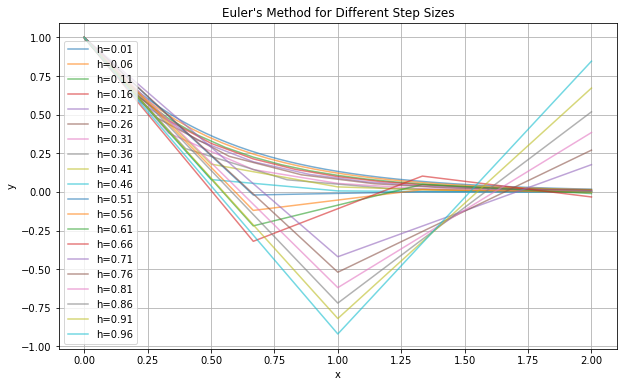

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Function dy/dx = -2y
def f(x, y):
    return -2 * y

# Euler method as a function
def euler_method(h):
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values


# Store all runs
results = {}

# Step sizes from 0.01 to 1 with step 0.05
h_values = np.arange(0.01, 1.01, 0.05)

# Run all simulations
for h in h_values:
    x_vals, y_vals = euler_method(h)
    results[h] = (x_vals, y_vals)

# Reference run (first run, smallest h)
h_ref = h_values[0]
x_ref, y_ref = results[h_ref]

print(f"\nReference step size: h = {h_ref}\n")

# Plot all runs
plt.figure(figsize=(10, 6))

for h in h_values:
    x_vals, y_vals = results[h]

    # Plot each run
    plt.plot(x_vals, y_vals, label=f"h={round(h,2)}", alpha=0.6)

    # Interpolate reference onto current grid for fair comparison
    y_ref_interp = np.interp(x_vals, x_ref, y_ref)

    # Compute pointwise error
    point_error = np.abs(y_vals - y_ref_interp)

    # Total accumulated error
    total_error = np.sum(point_error)

    print(f"Step size h = {round(h,2)}")
    print("Pointwise error:", point_error)
    print("Total accumulated error:", total_error)
    print("-" * 50)

# Plot formatting
plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for Different Step Sizes")
plt.legend()
plt.grid()
plt.show()